# Customer Churn Prediction

Predicting which Telco customers are likely to cancel their subscription, using the IBM Telco Customer Churn dataset (7,043 customers, 21 features).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.shape

(7043, 21)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data cleaning

`TotalCharges` is stored as an object column instead of numeric — a quick look shows some rows have blank strings instead of a number. These all turn out to be customers with `tenure == 0`, i.e. brand new customers who haven't been billed yet.

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isna().sum()

np.int64(11)

In [6]:
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [7]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df = df.drop(columns=["customerID"])

## Exploratory data analysis

In [8]:
churn_rate = df["Churn"].value_counts(normalize=True)
churn_rate

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

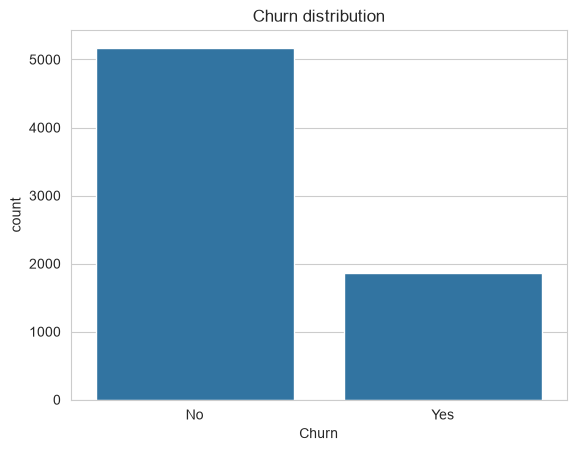

In [9]:
sns.countplot(data=df, x="Churn")
plt.title("Churn distribution")
plt.savefig("../results/churn_distribution.png", bbox_inches="tight")
plt.show()

About 27% of customers churned. That's an imbalanced target, which matters later — a model that just predicts "No" every time would already be 73% accurate without being useful, so accuracy alone won't tell us much.

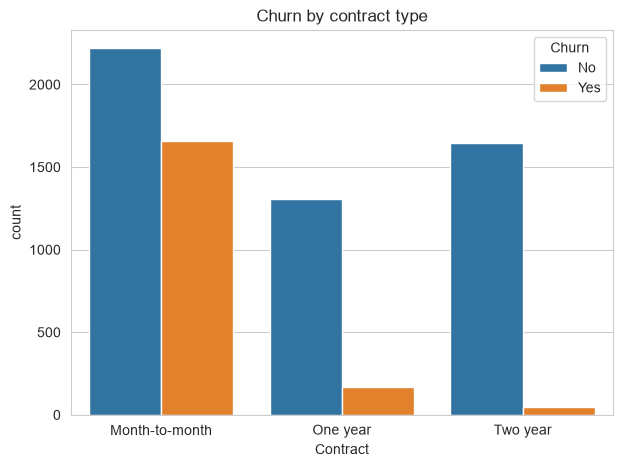

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by contract type")
plt.savefig("../results/churn_by_contract.png", bbox_inches="tight")
plt.show()

Month-to-month customers churn far more than customers on one or two year contracts. That makes intuitive sense — there's no penalty for leaving, so contract type looks like it'll be one of the strongest predictors.

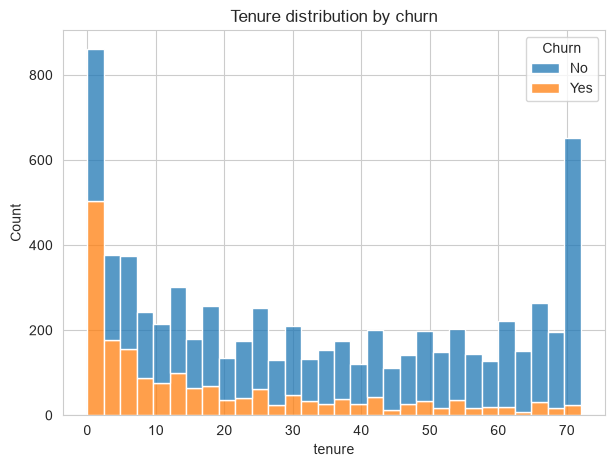

In [11]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="stack")
plt.title("Tenure distribution by churn")
plt.savefig("../results/tenure_by_churn.png", bbox_inches="tight")
plt.show()

Churn is heavily concentrated in the first few months. Customers who stick around past year one are much less likely to leave.

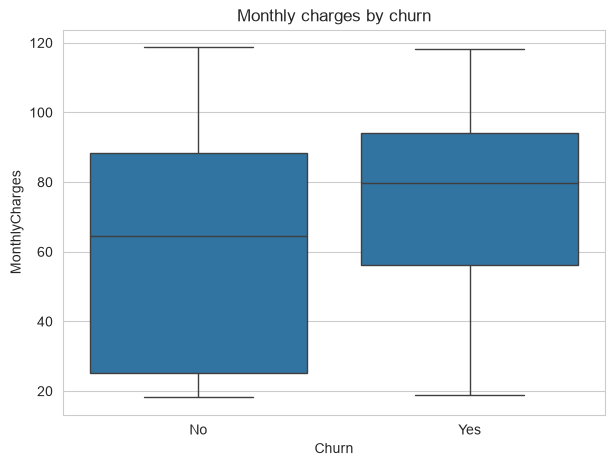

In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly charges by churn")
plt.savefig("../results/charges_by_churn.png", bbox_inches="tight")
plt.show()

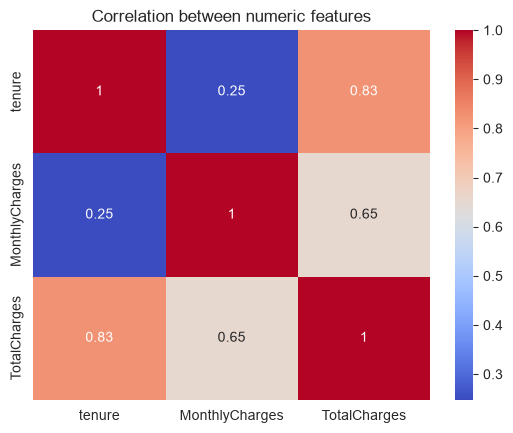

In [13]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between numeric features")
plt.savefig("../results/correlation_heatmap.png", bbox_inches="tight")
plt.show()

`TotalCharges` is basically `tenure * MonthlyCharges`, so it's highly correlated with tenure. Worth keeping in mind for feature engineering — it's not adding much independent information.

## Feature engineering

Most columns are categorical text (`Yes`/`No`, service types, contract type, etc.), so they need to be converted to numbers before a model can use them. Binary columns (`Yes`/`No`, `Male`/`Female`) get label encoded; columns with more than two categories get one-hot encoded so the model doesn't assume a false order between them.

In [14]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

df.shape

(7043, 31)

## Train/test split and scaling

In [15]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((5634, 30), (1409, 30))

## Baseline model: Logistic Regression

Starting with Logistic Regression because it's simple, fast, and gives a baseline to compare more complex models against. If a more complicated model can't beat this, it's not worth the extra complexity.

Logistic Regression is sensitive to feature scale — `tenure`, `MonthlyCharges` and `TotalCharges` range into the thousands while the one-hot columns are just 0/1, which stops the solver from converging cleanly. Scaling the numeric columns fixes that.

In [16]:
scaler = StandardScaler()
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

In [17]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=["No churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

    No churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8421710713270816


## Random Forest

Trying a Random Forest next to see if capturing non-linear relationships and feature interactions improves on the linear baseline.

In [18]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=["No churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

    No churn       0.84      0.91      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8408160892815624


## Comparing the two models

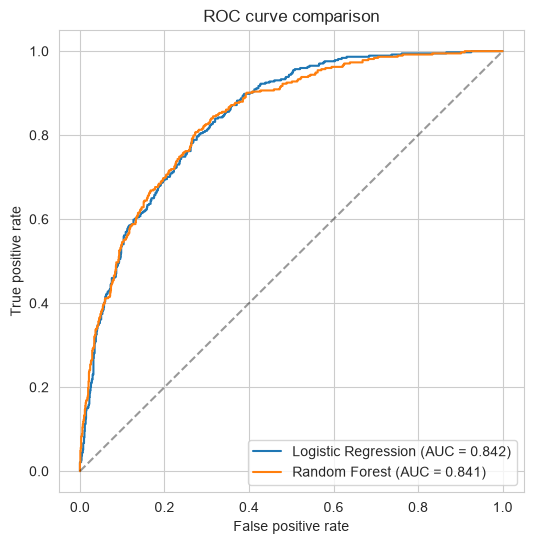

In [19]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve comparison")
plt.legend()
plt.savefig("../results/roc_comparison.png", bbox_inches="tight")
plt.show()

Logistic Regression and Random Forest come out very close on ROC-AUC. For a dataset like this, where most features are already fairly linearly related to churn (contract type, tenure), Random Forest's ability to model non-linear interactions doesn't add much. Logistic Regression is also more interpretable, so it's a reasonable choice to go with in practice.

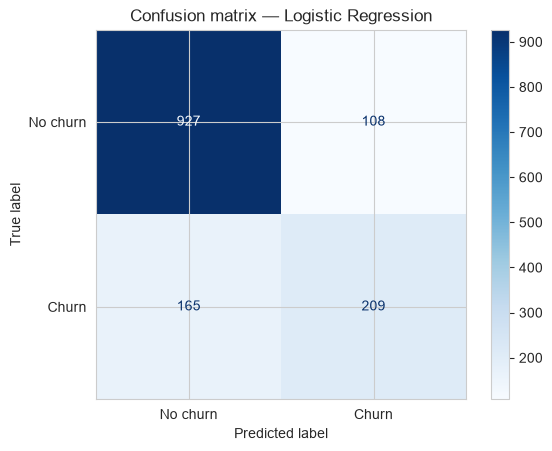

In [20]:
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=["No churn", "Churn"]).plot(cmap="Blues")
plt.title("Confusion matrix — Logistic Regression")
plt.savefig("../results/confusion_matrix.png", bbox_inches="tight")
plt.show()

## Feature importance

Using the Random Forest's built-in feature importances to see which factors matter most for churn — useful for a business audience even if Logistic Regression ends up being the model of choice.

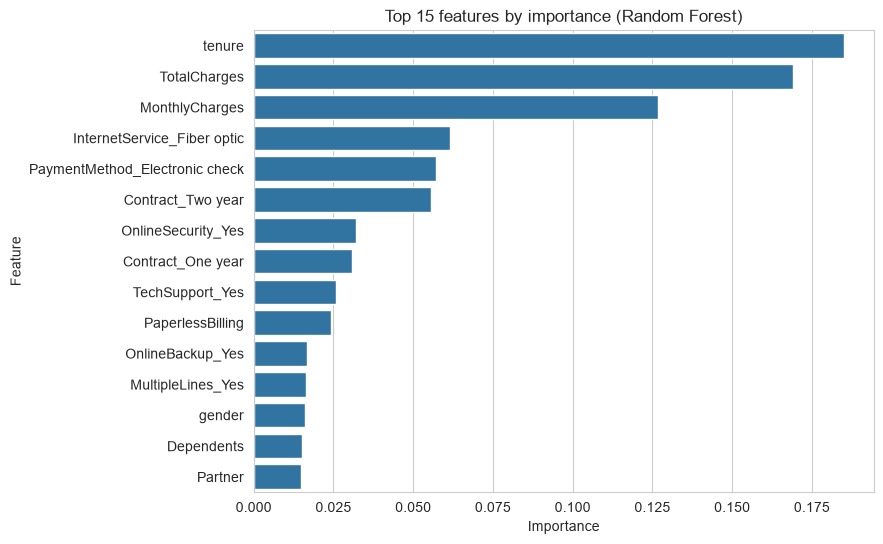

In [21]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 features by importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("../results/feature_importance.png", bbox_inches="tight")
plt.show()

Tenure, monthly charges, total charges, and contract type dominate — consistent with what the EDA already suggested. Customers on month-to-month contracts with high monthly charges and low tenure are the highest-risk group.

## Conclusion

Both models land around 0.83-0.84 ROC-AUC, with recall on the churn class around 0.55-0.60 — the models catch roughly half to two-thirds of churners, which is a reasonable starting point but leaves room for improvement (see README for a full discussion of limitations and next steps).

The strongest churn signals are contract type, tenure, and monthly charges. In practice, this points to a fairly simple retention strategy: offer incentives to switch month-to-month customers onto longer contracts, and pay closer attention to customers in their first few months.